# 🏗️ 베이스라인 모델 구축: 5클래스 대화 분류

---

## 프로젝트 개요

| 항목 | 내용 |
|---|---|
| **과제** | 대화의 성격을 5개 클래스 중 하나로 분류 |
| **클래스** | `협박 대화`, `갈취 대화`, `직장 내 괴롭힘 대화`, `기타 괴롭힘 대화`, `일반 대화` |
| **평가 지표** | Macro F1 Score |
| **모델** | KLUE-RoBERTa-base (Fine-tuning) |
| **데이터** | `baseline.csv` — 위협 4클래스(증강) + 일반 대화(합성) |

### 참조 문서
- `docs/DLThon.md`: 대회 규칙 및 평가 항목
- `docs/strategy.md`: EDA 기반 데이터 전략 보고서
- `reports/eda_results.txt`: EDA 분석 수치
- `model_plan.md`: 모델 구현 계획서

---

## 1. 환경 설정 및 라이브러리 임포트

학습에 필요한 모든 라이브러리를 로드합니다.

| 라이브러리 | 용도 |
|---|---|
| `transformers` | KLUE-RoBERTa 모델 및 토크나이저 |
| `torch` | 모델 정의, 학습, 추론 |
| `sklearn` | 데이터 분할, F1 Score 계산, 혼동 행렬 |
| `pandas`, `numpy` | 데이터 처리 |
| `matplotlib`, `seaborn` | 시각화 |

In [21]:
# ============================================================
# Cell 1: 환경 설정 및 라이브러리 임포트
# ============================================================

# --- 기본 라이브러리 ---
import pandas as pd
import numpy as np
import re
import os
import warnings
warnings.filterwarnings('ignore')

# --- PyTorch ---
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# --- HuggingFace Transformers ---
from transformers import AutoTokenizer, AutoModel
from transformers import get_linear_schedule_with_warmup

# --- 평가 ---
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# --- 시각화 ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- 한글 폰트 설정 (Windows 기준) ---
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# --- 재현성 보장을 위한 시드 고정 ---
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)

# --- GPU 확인 ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 디바이스: {device}')
if device.type == 'cuda':
    print(f'GPU 이름: {torch.cuda.get_device_name(0)}')
    print(f'GPU 메모리: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

사용 디바이스: cuda
GPU 이름: NVIDIA GeForce RTX 3050 Laptop GPU
GPU 메모리: 4.3 GB


---

## 2. 데이터 로드 및 전처리

### 2-1. 데이터 로드

`baseline.csv`는 팀원이 다음 작업을 완료한 최종 학습 데이터입니다:
- **위협 4클래스**: 원본 데이터 + 증강(동의어 교체, 역번역 등)
- **일반 대화**: LLM 기반 합성 데이터 (~1,000건)
- **중복 제거**: 완전 중복(104건) + 준-중복(117건) 제거 완료

### 2-2. 텍스트 전처리 전략

| 처리 항목 | 결정 | 근거 (실전 데이터 통일 전략) |
|---|---|---|
| **줄바꿈 (`\n`)** | **공백(` `)으로 치환** | 실전(`test.csv`)에 개행이 없으므로, 구조적 편향을 막기 위해 모든 클래스를 단일 라인으로 평탄화 |
| `!`, `?` | 유지 | 문장 종결 및 감정 상태를 나타내는 중요한 힌트이므로 보존 |
| 이모티콘 | 별도 처리 불필요 | 학습 데이터 전체에서 0건 |
| 조사 (`을`, `를`) | 유지 | BERT 계열 모델이 문법 정보를 활용하도록 방치 |


In [22]:
# ============================================================
# Cell 2: 데이터 로드 및 전처리
# ============================================================

# --- 2-1. 데이터 로드 ---
# train_final.csv: 증강/합성이 완료된 최종 학습 데이터
# val_final.csv: 격리된 최종 검증 데이터
train_df = pd.read_csv('../data/train_final_v5_1.csv')
val_df = pd.read_csv('../data/val_final_v5_1.csv')

print(f'Train 데이터 크기: {train_df.shape}')
print(f'Val   데이터 크기: {val_df.shape}')
print(f'\n=== Train 클래스 분포 ===')
print(train_df['class'].value_counts())
print(f'\n=== Val 클래스 분포 ===')
print(val_df['class'].value_counts())


Train 데이터 크기: (15000, 3)
Val   데이터 크기: (967, 3)

=== Train 클래스 분포 ===
class
갈취 대화          3000
협박 대화          3000
일반 대화          3000
기타 괴롭힘 대화      3000
직장 내 괴롭힘 대화    3000
Name: count, dtype: int64

=== Val 클래스 분포 ===
class
일반 대화          200
기타 괴롭힘 대화      200
갈취 대화          195
직장 내 괴롭힘 대화    194
협박 대화          178
Name: count, dtype: int64


In [23]:
# ============================================================
# Cell 3: 레이블 인코딩 + 텍스트 전처리
# ============================================================

# 레이블 매핑 정의
label2id = {
    '갈취 대화': 0,
    '기타 괴롭힘 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '협박 대화': 3,
    '일반 대화': 4,
}
id2label = {v: k for k, v in label2id.items()}

# 레이블 컬럼 생성 (Train & Val)
train_df['label'] = train_df['class'].map(label2id)
val_df['label'] = val_df['class'].map(label2id)

print('레이블 매핑 완료 (Train & Val)')
print(f'클래스 수: {len(label2id)}개')


레이블 매핑 완료 (Train & Val)
클래스 수: 5개


In [24]:
# ============================================================
# Cell 4: 텍스트 전처리 함수
# ============================================================

def preprocess(text):
    """
    대화 텍스트를 모델 입력에 적합한 형태로 변환합니다 (실전 데이터 정합성 버전).
    
    기존의 [SEP] 치환 전략 대신, 실전(test.csv)과 동일하게 
    모든 발화를 공백으로 연결하여 단일 문맥으로 처리합니다.
    """
    if not isinstance(text, str):
        return ""
        
    # 1. 혹시 남아있을 수 있는 줄바꿈을 공백으로 치환
    text = text.replace('\n', ' ')
    
    # 2. 연속된 공백을 단일 공백으로 정리 (정규화)
    import re
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

# 전처리 적용 (Train & Val)
train_df['text'] = train_df['conversation'].apply(preprocess)
val_df['text'] = val_df['conversation'].apply(preprocess)

print(f'전처리 완료: Train({len(train_df)}), Val({len(val_df)})')


# 전처리 결과 확인
print('=== 전처리 전 (원본) ===')
print(train_df['conversation'].iloc[0][:200])
print(f'\n=== 전처리 후 ===')
print(train_df['text'].iloc[0][:200])
print(f'\n전처리 완료: {len(train_df)}건')

전처리 완료: Train(15000), Val(967)
=== 전처리 전 (원본) ===
나 머무 지쳤어 나 미치는 꼴 보고 싶어서 그래? 내가 죽어야 너가 정신차리지? 나 정말 힘들어서 그래 그만하자 내가 잘못되면 다 너때문인줄 알아. 왜그러는거야. 내가 그냥하는 말 같아? 나 지금 옥상이야. 거길 왜 갔어. 진정하고 내려와. 헤어지자는 말 취소해 지금 당장 죽어버리기 전에 말해. 알겠어 취소할게.그러니까 옥상에서 내려와. 진작에 그랬어야지

=== 전처리 후 ===
나 머무 지쳤어 나 미치는 꼴 보고 싶어서 그래? 내가 죽어야 너가 정신차리지? 나 정말 힘들어서 그래 그만하자 내가 잘못되면 다 너때문인줄 알아. 왜그러는거야. 내가 그냥하는 말 같아? 나 지금 옥상이야. 거길 왜 갔어. 진정하고 내려와. 헤어지자는 말 취소해 지금 당장 죽어버리기 전에 말해. 알겠어 취소할게.그러니까 옥상에서 내려와. 진작에 그랬어야지

전처리 완료: 15000건


---

## 3. Train / Validation 분할

학습 안정성과 일반화 성능을 평가하기 위해 데이터를 **80:20** 비율로 분할합니다.

| 파라미터 | 설정 | 이유 |
|---|---|---|
| 분할 비율 | 80:20 | 데이터가 ~5,000건으로 적으므로 검증 셋이 최소 1,000건은 확보되어야 함 |
| 층화 추출 (Stratify) | `label` 기준 | 클래스 비율이 Train/Val에서 동일하게 유지되도록 |
| Random Seed | 42 | 재현성 보장 |

In [25]:
# ============================================================
# Cell 5: Train/Validation 분할
# ============================================================


# 이미 물리적으로 분산된 파일을 직접 로드했으므로, 리스트로 속성 추출만 수행
train_texts = train_df['text'].tolist()
train_labels = train_df['label'].tolist()
val_texts = val_df['text'].tolist()
val_labels = val_df['label'].tolist()

print(f'데이터셋 준비 완료 | Train: {len(train_texts)}건, Val: {len(val_texts)}건')

# 클래스 비율 최종 확인
print(f'\n=== Train 클래스 분포 (%) ===')
print(train_df['class'].value_counts(normalize=True) * 100)


데이터셋 준비 완료 | Train: 15000건, Val: 967건

=== Train 클래스 분포 (%) ===
class
갈취 대화          20.0
협박 대화          20.0
일반 대화          20.0
기타 괴롭힘 대화      20.0
직장 내 괴롭힘 대화    20.0
Name: proportion, dtype: float64


---

## 4. 토크나이저 및 Dataset 정의

### 4-1. 토크나이저: KLUE-RoBERTa

KLUE-RoBERTa의 전용 토크나이저(BPE 기반)를 사용합니다.  
한국어 텍스트를 서브워드 단위로 분절하여 OOV(미등록 단어) 문제를 최소화합니다.

### 4-2. MAX_LEN = 256 설정 근거

| EDA 수치 | 값 |
|---|---|
| 글자 수 중간값 | 203자 |
| 글자 수 75% | 270자 |
| 글자 수 최대 | 874자 |

- RoBERTa 토크나이저는 한국어 1글자당 약 1~2 토큰을 생성
- **256 토큰**이면 대부분의 대화(75%)를 완전히 커버
- 512 대비 **메모리 50% 절약** → 배치 사이즈 증가 가능

In [26]:
# ============================================================
# Cell 6: 토크나이저 및 하이퍼파라미터 설정
# ============================================================

# --- 모델 이름 ---
# KLUE-RoBERTa-base: 한국어 특화 사전학습 모델
# - BERT 대비 Dynamic Masking + NSP 제거로 문맥 파악 능력 향상
# - 110M 파라미터로 Ablation Study 반복에 적합한 크기
MODEL_NAME = 'klue/roberta-base'

# --- 하이퍼파라미터 ---
MAX_LEN = 256       # 토큰 최대 길이 (EDA: 글자 중간값 203, 75%=270)
BATCH_SIZE = 32     # 배치 크기 (MAX_LEN=256 기준 GPU 메모리 최적)
LEARNING_RATE = 2e-5  # Fine-tuning 표준 범위 (1e-5 ~ 5e-5)
EPOCHS = 30         # 학습 에폭 (데이터 ~5,000건 → 3~5 에폭에서 수렴 예상)
WARMUP_RATIO = 0.1  # 학습 초기 10%는 워밍업 (불안정 방지)
WEIGHT_DECAY = 0.01 # L2 정규화 계수 (과적합 억제)
DROPOUT_RATE = 0.3  # 분류 헤드 드롭아웃 (데이터 적으므로 0.1보다 높게)

# --- 토크나이저 로드 ---
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f'모델: {MODEL_NAME}')
print(f'MAX_LEN: {MAX_LEN}')
print(f'BATCH_SIZE: {BATCH_SIZE}')
print(f'LEARNING_RATE: {LEARNING_RATE}')
print(f'EPOCHS: {EPOCHS}')
print(f'DROPOUT_RATE: {DROPOUT_RATE}')
print(f'Vocab Size: {tokenizer.vocab_size}')

# --- 토크나이저 동작 확인 ---
sample_text = train_texts[0][:100]
tokens = tokenizer.tokenize(sample_text)
print(f'\n=== 토크나이저 동작 확인 ===')
print(f'원문 ({len(sample_text)}자): {sample_text}')
print(f'토큰 ({len(tokens)}개): {tokens[:20]}...')

모델: klue/roberta-base
MAX_LEN: 256
BATCH_SIZE: 32
LEARNING_RATE: 2e-05
EPOCHS: 30
DROPOUT_RATE: 0.3
Vocab Size: 32000

=== 토크나이저 동작 확인 ===
원문 (100자): 나 머무 지쳤어 나 미치는 꼴 보고 싶어서 그래? 내가 죽어야 너가 정신차리지? 나 정말 힘들어서 그래 그만하자 내가 잘못되면 다 너때문인줄 알아. 왜그러는거야. 내가 그냥하는 말
토큰 (58개): ['나', '머무', '지쳤', '##어', '나', '미치', '##는', '꼴', '보고', '싶', '##어', '##서', '그래', '?', '내', '##가', '죽', '##어야', '너', '##가']...


In [27]:
# ============================================================
# Cell 7: PyTorch Dataset 클래스 정의
# ============================================================

class ConversationDataset(Dataset):
    """
    대화 텍스트를 KLUE-RoBERTa 입력 형식으로 변환하는 Dataset 클래스.
    
    각 샘플은 다음으로 구성됩니다:
    - input_ids: 토큰 ID 시퀀스 (0~vocab_size)
    - attention_mask: 실제 토큰(1) vs 패딩(0) 구분
    - label: 정수 레이블 (0~4)
    """
    
    def __init__(self, texts, labels, tokenizer, max_len):
        """
        Args:
            texts (list[str]): 전처리된 텍스트 리스트
            labels (list[int]): 정수 레이블 리스트
            tokenizer: HuggingFace 토크나이저
            max_len (int): 최대 토큰 수
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
    
    def __len__(self):
        return len(self.texts)
    
    def __getitem__(self, idx):
        # 텍스트를 토큰화하여 모델 입력 형식으로 변환
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,      # 최대 길이 제한
            padding='max_length',         # 짧은 시퀀스는 패딩
            truncation=True,              # 긴 시퀀스는 잘라냄
            return_tensors='pt',          # PyTorch 텐서 반환
        )
        
        return {
            'input_ids': encoding['input_ids'].squeeze(0),         # (MAX_LEN,)
            'attention_mask': encoding['attention_mask'].squeeze(0), # (MAX_LEN,)
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }


# --- Dataset 생성 ---
train_dataset = ConversationDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = ConversationDataset(val_texts, val_labels, tokenizer, MAX_LEN)

# --- DataLoader 생성 ---
# Train: shuffle=True (매 에폭마다 데이터 순서 섞기)
# Val: shuffle=False (평가 시에는 순서 유지)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f'Train Dataset: {len(train_dataset)}건 → {len(train_loader)} 배치')
print(f'Val   Dataset: {len(val_dataset)}건 → {len(val_loader)} 배치')

# --- 배치 형태 확인 ---
sample_batch = next(iter(train_loader))
print(f'\n=== 배치 형태 확인 ===')
print(f"input_ids shape:      {sample_batch['input_ids'].shape}")       # (BATCH, MAX_LEN)
print(f"attention_mask shape: {sample_batch['attention_mask'].shape}")  # (BATCH, MAX_LEN)
print(f"label shape:          {sample_batch['label'].shape}")           # (BATCH,)

Train Dataset: 15000건 → 469 배치
Val   Dataset: 967건 → 31 배치

=== 배치 형태 확인 ===
input_ids shape:      torch.Size([32, 256])
attention_mask shape: torch.Size([32, 256])
label shape:          torch.Size([32])


---

## 5. 모델 정의

### 아키텍처 구조

```
[입력 텍스트]
    │
    ▼
KLUE-RoBERTa-base (768 hidden dim)
    │
    ▼
[CLS] 토큰 출력 (768차원) ← 대화 전체의 의미를 응축한 벡터
    │
    ▼
Dropout (p=0.3) ← 전략적 증강 데이터(~15,000건)에 대한 과적합 방지
    │
    ▼
Linear (768 → 5) ← 5클래스 분류
    │
    ▼
[Logits] → CrossEntropyLoss

```

[설계 결정 근거]
| 결정 | 선택 | 근거 |
|---|---|---|
| 풀링 방식 | [CLS] 토큰 | 문장 분류 태스크 표준. 문맥 전체 의미를 파악하는 최고 안정적 방식 |
| Dropout | 0.3 | 증강을 통해 데이터가 15,000건으로 늘었으나, 패턴 과적합을 막기 위해 0.3 유지 |
| 분류 헤드 | 단일 Linear | 베이스라인의 안정성을 위해 단순 구조 채택. 추후 MLP 고도화 예정 |

In [ ]:
# ============================================================
# Cell 8: 분류 모델 정의 (Full Fine-tuning + Enhanced Head)
# ============================================================

class ConversationClassifier(nn.Module):
    """
    KLUE-RoBERTa 기반 대화 분류 모델 (Full Fine-tuning Version).
    
    [설계 철학]
    합성 데이터와 원본 데이터의 양이 충분하고(약 15,000건 이상), 일반 대화 데이터의 품질이
    확보된 경우 백본 전체를 학습시키는 것이 성능 극대화에 유리합니다.
    
    [구조]
    1. KLUE-RoBERTa backbone (Trainable) -> 전체 가중치 업데이트
    2. Mean Pooling -> 대화 전체의 문맥 정보 통합
    3. LayerNorm -> 입력 분포 안정화
    4. Enhanced Head: FC(768->256) + GELU + Dropout + FC(256->5)
    """
    
    def __init__(self, model_name, num_classes=5, dropout_rate=0.3):
        super().__init__()
        
        # ========== 백본 로드 (학습 가능 상태) ==========
        self.backbone = AutoModel.from_pretrained(model_name)
        hidden_size = self.backbone.config.hidden_size  # 768
        
        # ========== 강화된 분류 헤드 (Multi-Layer Head) ==========
        # 백본이 학습되더라도, 헤드가 복잡할수록 백본에서 추출된 특징을 
        # 더 세밀하게 분류할 수 있습니다.
        
        self.layer_norm = nn.LayerNorm(hidden_size)
        self.fc1 = nn.Linear(hidden_size, 256)
        self.activation = nn.GELU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(256, num_classes)
    
    def mean_pooling(self, last_hidden_state, attention_mask):
        """
        [CLS] 토큰 대신 전체 토큰의 벡터를 평균하여 대화 전체의 의미를 포착합니다.
        """
        mask_expanded = attention_mask.unsqueeze(-1).float()
        sum_embeddings = torch.sum(last_hidden_state * mask_expanded, dim=1)
        sum_mask = mask_expanded.sum(dim=1).clamp(min=1e-9)
        return sum_embeddings / sum_mask
    
    def forward(self, input_ids, attention_mask):
        # Step 1: RoBERTa 백본 통과 (전체 가중치에 대해 기울기 계산)
        outputs = self.backbone(
            input_ids=input_ids,
            attention_mask=attention_mask,
        )
        
        # Step 2: Mean Pooling
        pooled_output = self.mean_pooling(outputs.last_hidden_state, attention_mask)
        
        # Step 3: LayerNorm
        pooled_output = self.layer_norm(pooled_output)
        
        # Step 4: FC1 + GELU + Dropout
        hidden = self.fc1(pooled_output)
        hidden = self.activation(hidden)
        hidden = self.dropout(hidden)
        
        # Step 5: 최종 분류 로짓 출력
        logits = self.fc2(hidden)
        
        return logits


# --- 모델 인스턴스 생성 ---
# freeze_backbone 인자를 제거하고 전체 학습 모드로 설정합니다.
model = ConversationClassifier(
    model_name=MODEL_NAME,
    num_classes=len(label2id),
    dropout_rate=DROPOUT_RATE,
).to(device)

# --- 파라미터 수 확인 ---
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'\n{"="*50}')
print(f'모드: Full Fine-tuning (전체 학습)')
print(f'전체 파라미터: {total_params:,}개')
print(f'학습 가능 파라미터: {trainable_params:,}개 ({trainable_params/total_params*100:.2f}%)')
print(f'{"="*50}')


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: klue/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


[Freeze] 백본 가중치 고정 완료 — 분류 헤드만 학습합니다.

전체 파라미터: 110,817,797개
학습 가능 파라미터: 199,685개 (0.1802%)
고정된 파라미터: 110,618,112개
모델 구조:
ConversationClassifier(
  (backbone): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(32000, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (outp

---

## 6. 학습 설정

### 옵티마이저 & 스케줄러

| 구성 요소 | 선택 | 근거 |
|---|---|---|
| **옵티마이저** | AdamW | BERT fine-tuning 표준. Weight Decay를 적용하여 L2 정규화 |
| **스케줄러** | Linear Warmup + Decay | 초기 10% 구간은 LR을 서서히 올려 학습 안정화 |
| **손실 함수** | CrossEntropyLoss | 다중 클래스 분류 표준 |
| **Gradient Clipping** | `max_norm=1.0` | 그래디언트 폭발 방지 |

In [33]:
# ============================================================
# Cell 9: 옵티마이저, 스케줄러, 손실 함수 설정
# ============================================================

# --- 옵티마이저: AdamW ---
# AdamW = Adam + Weight Decay (L2 정규화)
# BERT/RoBERTa fine-tuning의 사실상 표준 옵티마이저
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,        # 2e-5
    weight_decay=WEIGHT_DECAY,  # 0.01
)

# --- 스케줄러: Linear Warmup + Decay ---
# 학습 초기 10%는 LR을 0에서 서서히 올림 (워밍업) → 이후 선형 감소
# 이유: 사전학습된 가중치를 갑자기 큰 LR로 업데이트하면 붕괴 위험
total_steps = len(train_loader) * EPOCHS  # 전체 학습 스텝 수
warmup_steps = int(total_steps * WARMUP_RATIO)  # 워밍업 스텝 수

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

# --- 손실 함수: CrossEntropyLoss ---
# 다중 클래스 분류의 표준 손실 함수
# 내부적으로 Softmax + NLLLoss를 결합
#
# [참고] 클래스 불균형이 심할 경우 아래처럼 가중치 적용 가능:
# class_counts = train_df['label'].value_counts().sort_index().values
# class_weights = 1.0 / torch.tensor(class_counts, dtype=torch.float)
# class_weights = class_weights / class_weights.sum() * len(class_weights)
# criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
criterion = nn.CrossEntropyLoss()

print(f'Total steps: {total_steps}')
print(f'Warmup steps: {warmup_steps}')
print(f'Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Scheduler: Linear Warmup + Decay')
print(f'Loss: CrossEntropyLoss')

Total steps: 14070
Warmup steps: 1407
Optimizer: AdamW (lr=2e-05, wd=0.01)
Scheduler: Linear Warmup + Decay
Loss: CrossEntropyLoss


---

## 7. 학습 실행

### 학습 루프 구조

각 에폭마다 다음을 수행합니다:

1. **학습(Train)**: 전체 Train 데이터를 순회하며 모델 가중치 업데이트
2. **검증(Validation)**: 전체 Val 데이터에 대해 손실과 F1 Score 측정
3. **Best Model 저장**: Val F1이 갱신되면 모델 가중치를 저장

### 핵심 기법

| 기법 | 설명 |
|---|---|
| **Gradient Clipping** | 그래디언트 크기를 `max_norm=1.0`으로 제한하여 폭발 방지 |
| **Best Model 저장** | Val F1 기준으로 최고 성능 모델만 보존 (Early Stopping 대용) |

In [34]:
# ============================================================
# Cell 10: 학습 & 검증 함수 정의 (tqdm 게이지 추가 버전)
# ============================================================
from tqdm.auto import tqdm

def train_epoch(model, loader, criterion, optimizer, scheduler, device):
    """
    1 에폭 학습을 수행합니다.
    
    Returns:
        avg_loss (float): 평균 손실
        f1 (float): Macro F1 Score
    """
    model.train()  # 학습 모드 (Dropout 활성화)
    total_loss = 0
    all_preds, all_trues = [], []
    
    # --- tqdm 진행바 설정 ---
    pbar = tqdm(loader, desc="  Training", leave=False)
    
    for batch in pbar:
        # --- 데이터를 GPU로 전송 ---
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)
        
        # --- Forward pass ---
        optimizer.zero_grad()  # 이전 그래디언트 초기화
        logits = model(input_ids, attention_mask)  # (batch, 5)
        loss = criterion(logits, labels)
        
        # --- Backward pass ---
        loss.backward()  # 그래디언트 계산
        
        # Gradient Clipping: 그래디언트가 1.0을 초과하면 스케일링
        # → 학습 안정성 확보 (RoBERTa fine-tuning 시 권장)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()   # 가중치 업데이트
        scheduler.step()   # 러닝 레이트 스케줄 업데이트
        
        # --- 메트릭 수집 ---
        total_loss += loss.item()
        all_preds.extend(logits.argmax(dim=-1).cpu().numpy())  # 예측 클래스
        all_trues.extend(labels.cpu().numpy())                 # 정답 클래스
        
        # --- 진행바 상태 업데이트 ---
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_trues, all_preds, average='macro')  # Macro F1
    return avg_loss, f1


def evaluate(model, loader, criterion, device):
    """
    검증/테스트를 수행합니다.
    
    Returns:
        avg_loss (float): 평균 손실
        f1 (float): Macro F1 Score
        all_preds (list): 전체 예측값
        all_trues (list): 전체 정답값
    """
    model.eval()  # 평가 모드 (Dropout 비활성화)
    total_loss = 0
    all_preds, all_trues = [], []
    
    # --- tqdm 진행바 설정 ---
    pbar = tqdm(loader, desc="  Evaluating", leave=False)
    
    with torch.no_grad():  # 그래디언트 계산 비활성화 (메모리/속도 절약)
        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)
            
            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)
            
            total_loss += loss.item()
            all_preds.extend(logits.argmax(dim=-1).cpu().numpy())
            all_trues.extend(labels.cpu().numpy())
            
            # --- 진행바 상태 업데이트 ---
            pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_trues, all_preds, average='macro')
    return avg_loss, f1, all_preds, all_trues


print('학습/검증 함수 정의 완료 (tqdm 적용)')


학습/검증 함수 정의 완료 (tqdm 적용)


In [ ]:
# ============================================================
# Cell 11: 메인 학습 루프 실행 (진행바 및 시간 측정 추가)
# ============================================================
from tqdm.auto import tqdm
import time

best_f1 = 0         # 최고 Val F1 기록
history = []         # 에폭별 학습 기록

print('=' * 70)
print(f'학습 시작 | 모델: {MODEL_NAME} | 디바이스: {device}')
print(f'Train: {len(train_dataset)}건 | Val: {len(val_dataset)}건 | Epochs: {EPOCHS}')
print('=' * 70)

for epoch in range(EPOCHS):
    epoch_start_time = time.time()  # 에폭 시작 시간 기록
    
    # --- 학습 ---
    # train_epoch 함수 내부에서도 tqdm을 쓸 수 있지만, 
    # 루프 밖에서 에폭 상황을 먼저 출력합니다.
    print(f'\n[Epoch {epoch+1}/{EPOCHS}]')
    
    train_loss, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, scheduler, device
    )
    
    # --- 검증 ---
    val_loss, val_f1, val_preds, val_trues = evaluate(
        model, val_loader, criterion, device
    )
    
    epoch_end_time = time.time()   # 에폭 종료 시간 기록
    epoch_duration = epoch_end_time - epoch_start_time
    
    # --- 에폭별 기록 저장 ---
    history.append({
        'epoch': epoch + 1,
        'train_loss': train_loss,
        'train_f1': train_f1,
        'val_loss': val_loss,
        'val_f1': val_f1,
        'lr': scheduler.get_last_lr()[0],
        'duration': epoch_duration
    })
    
    # --- 에폭 결과 출력 ---
    print(f'  >> Time: {epoch_duration:.2f}s')
    print(f'  >> Train | Loss: {train_loss:.4f} | F1: {train_f1:.4f}')
    print(f'  >> Val   | Loss: {val_loss:.4f} | F1: {val_f1:.4f}')
    print(f'  >> LR: {scheduler.get_last_lr()[0]:.2e}')
    
    # --- Best Model 저장 ---
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), 'best_model_v3.pt')
        print(f'  ✅ Best model saved! (Val F1: {best_f1:.4f})')

print('\n' + '=' * 70)
print(f'학습 완료 | Best Val F1: {best_f1:.4f}')
print('=' * 70)


학습 시작 | 모델: klue/roberta-base | 디바이스: cuda
Train: 15000건 | Val: 967건 | Epochs: 30

[Epoch 1/30]


  Training:   0%|          | 0/469 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

  >> Time: 452.31s
  >> Train | Loss: 1.5684 | F1: 0.3014
  >> Val   | Loss: 1.4715 | F1: 0.6668
  >> LR: 6.67e-06
  ✅ Best model saved! (Val F1: 0.6668)

[Epoch 2/30]


  Training:   0%|          | 0/469 [00:00<?, ?it/s]

...

  >> Time: 500.77s
  >> Train | Loss: 0.3562 | F1: 0.8786
  >> Val   | Loss: 0.3370 | F1: 0.8903
  >> LR: 1.48e-05

[Epoch 11/30]


  Training:   0%|          | 0/469 [00:00<?, ?it/s]

  Evaluating:   0%|          | 0/31 [00:00<?, ?it/s]

  >> Time: 512.63s
  >> Train | Loss: 0.3428 | F1: 0.8831
  >> Val   | Loss: 0.3287 | F1: 0.8866
  >> LR: 1.41e-05

[Epoch 12/30]


  Training:   0%|          | 0/469 [00:00<?, ?it/s]

---

## 8. 평가 및 분석

최적 모델(Best Val F1)을 로드하여 상세한 성능 분석을 수행합니다.

### 분석 항목

| 분석 | 목적 |
|---|---|
| **Classification Report** | 클래스별 Precision, Recall, F1 확인 |
| **혼동 행렬** | 어떤 클래스 쌍이 가장 많이 혼동되는지 시각화 |
| **학습 곡선** | 과적합 여부 (Train-Val Loss 격차) 확인 |

### 혼동 행렬 분석 포인트 (strategy.md 기반)
- `협박 ↔ 기타 괴롭힘`: 코사인 유사도 **0.87**로 가장 높음 → 혼동 예상
- `협박 ↔ 갈취`: 코사인 유사도 **0.83** → 두 번째 혼동 위험
- `일반 대화`: 위협 클래스로 오분류되는 비율 → 합성 데이터 품질 지표

In [ ]:
# ============================================================
# Cell 12: Best Model 로드 및 상세 평가
# ============================================================

# --- 최적 모델 로드 후 최종 검증 수행 ---
model.load_state_dict(torch.load('best_model_v4.pt'))
final_loss, final_f1, final_preds, final_trues = evaluate(model, val_loader, criterion, device)

# --- Classification Report ---
class_names = [id2label[i] for i in range(len(id2label))]
print('\n' + '=' * 60)
print('Classification Report (Best Model on Validation Set)')
print('=' * 60)
print(classification_report(
    final_trues, final_preds,
    target_names=class_names,
    digits=4,
))
print(f'Overall Macro F1: {final_f1:.4f}')


  Evaluating:   0%|          | 0/121 [00:00<?, ?it/s]


Classification Report (Best Model on Validation Set)
              precision    recall  f1-score   support

       갈취 대화     0.9171    0.9077    0.9124       195
   기타 괴롭힘 대화     0.9251    0.8650    0.8941       200
 직장 내 괴롭힘 대화     0.9360    0.9794    0.9572       194
       협박 대화     0.9011    0.9213    0.9111       178
       일반 대화     0.9901    1.0000    0.9950       200

    accuracy                         0.9349       967
   macro avg     0.9339    0.9347    0.9339       967
weighted avg     0.9347    0.9349    0.9344       967

Overall Macro F1: 0.9339


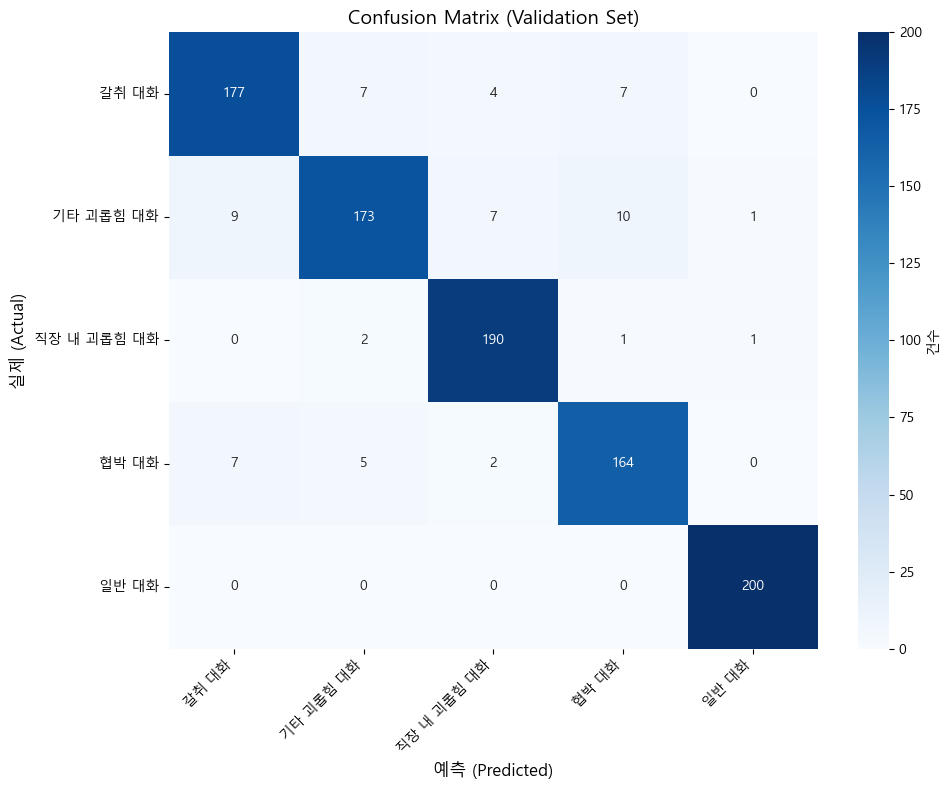


=== 오분류 분석 (상위 5건) ===
  1위: [기타 괴롭힘 대화] → [협박 대화]으로 10건 오분류
  2위: [기타 괴롭힘 대화] → [갈취 대화]으로 9건 오분류
  3위: [갈취 대화] → [기타 괴롭힘 대화]으로 7건 오분류
  4위: [갈취 대화] → [협박 대화]으로 7건 오분류
  5위: [기타 괴롭힘 대화] → [직장 내 괴롭힘 대화]으로 7건 오분류


In [ ]:
# ============================================================
# Cell 13: 혼동 행렬 시각화
# ============================================================

# 혼동 행렬 계산
cm = confusion_matrix(final_trues, final_preds)

# 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm, annot=True, fmt='d',
    xticklabels=class_names,
    yticklabels=class_names,
    cmap='Blues',
    cbar_kws={'label': '건수'},
)
plt.title('Confusion Matrix (Validation Set)', fontsize=14)
plt.ylabel('실제 (Actual)', fontsize=12)
plt.xlabel('예측 (Predicted)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 혼동 분석 ---
# 대각선 제외, 오분류가 가장 많은 쌍을 식별
print('\n=== 오분류 분석 (상위 5건) ===')
confusion_pairs = []
for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((
                class_names[i],  # 실제
                class_names[j],  # 예측
                cm[i][j],        # 건수
            ))
confusion_pairs.sort(key=lambda x: -x[2])
for rank, (actual, pred, count) in enumerate(confusion_pairs[:5], 1):
    print(f'  {rank}위: [{actual}] → [{pred}]으로 {count}건 오분류')

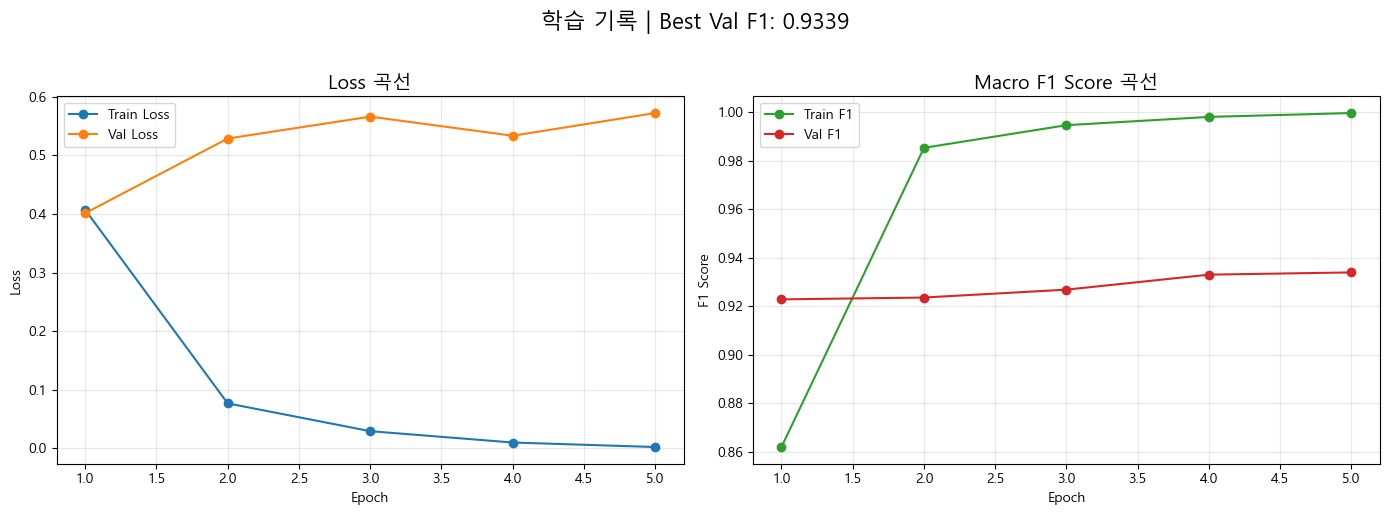


=== 에폭별 학습 기록 ===
 epoch  train_loss  train_f1  val_loss  val_f1     lr  duration
     1      0.4071    0.8620    0.4012  0.9228 0.0000 1483.8817
     2      0.0769    0.9853    0.5285  0.9236 0.0000 1566.5615
     3      0.0295    0.9946    0.5659  0.9269 0.0000 1566.6073
     4      0.0101    0.9980    0.5333  0.9330 0.0000 1566.5715
     5      0.0024    0.9996    0.5720  0.9339 0.0000 1566.5642


In [ ]:
# ============================================================
# Cell 14: 학습 곡선 시각화
# ============================================================

hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Loss 곡선 ---
axes[0].plot(hist_df['epoch'], hist_df['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
axes[0].plot(hist_df['epoch'], hist_df['val_loss'], 'o-', label='Val Loss', color='#ff7f0e')
axes[0].set_title('Loss 곡선', fontsize=14)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- F1 Score 곡선 ---
axes[1].plot(hist_df['epoch'], hist_df['train_f1'], 'o-', label='Train F1', color='#2ca02c')
axes[1].plot(hist_df['epoch'], hist_df['val_f1'], 'o-', label='Val F1', color='#d62728')
axes[1].set_title('Macro F1 Score 곡선', fontsize=14)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'학습 기록 | Best Val F1: {best_f1:.4f}', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# --- 학습 기록 테이블 출력 ---
print('\n=== 에폭별 학습 기록 ===')
print(hist_df.to_string(index=False, float_format='{:.4f}'.format))

---

## 9. 추론 및 제출 파일 생성

학습 완료된 최적 모델로 `test.csv`를 추론하여 `submission.csv`를 생성합니다.

### 추론 파이프라인

```
test.csv → 전처리(preprocess) → 토큰화 → 모델 추론(eval mode) → argmax → 레이블 디코딩 → submission.csv
```

In [ ]:
# ============================================================
# Cell 15: 추론 및 submission.csv 생성
# ============================================================

# --- 테스트 데이터 로드 ---
test_df = pd.read_csv('../data/test.csv')
print(f'테스트 데이터: {len(test_df)}건')
print(f'컬럼: {test_df.columns.tolist()}')

# --- 전처리 적용 (학습 시와 동일한 전처리) ---
test_df['text'] = test_df['conversation'].apply(preprocess)

# --- Dataset & DataLoader 생성 ---
# 테스트에는 레이블이 없으므로 더미 레이블(0)을 사용
test_dataset = ConversationDataset(
    texts=test_df['text'].tolist(),
    labels=[0] * len(test_df),  # 더미 레이블 (사용하지 않음)
    tokenizer=tokenizer,
    max_len=MAX_LEN,
)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# --- 최적 모델 로드 ---
model.load_state_dict(torch.load('best_model_v3.pt'))
model.eval()

# --- 추론 실행 ---
all_preds = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        logits = model(input_ids, attention_mask)
        preds = logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)

# --- 레이블 디코딩 ---
# --- 수정 코드 (모든 값을 문자열로 강제 변환) ---
test_df['class'] = [str(id2label[p]) for p in all_preds] 


# --- submission.csv 생성 ---
submission = test_df[['idx', 'class']]
submission.to_csv('submission.csv', index=False)

print('\n=== submission.csv 생성 완료 ===')
print(f'파일 크기: {len(submission)}건')
print(f'\n=== 예측 클래스 분포 ===')
print(submission['class'].value_counts())
print(f'\n=== 상위 5건 미리보기 ===')
print(submission.head())

테스트 데이터: 500건
컬럼: ['idx', 'conversation']

=== submission.csv 생성 완료 ===
파일 크기: 500건

=== 예측 클래스 분포 ===
class
기타 괴롭힘 대화      155
직장 내 괴롭힘 대화    124
갈취 대화          116
협박 대화          102
일반 대화            3
Name: count, dtype: int64

=== 상위 5건 미리보기 ===
     idx        class
0  t_000        갈취 대화
1  t_001  직장 내 괴롭힘 대화
2  t_002  직장 내 괴롭힘 대화
3  t_003    기타 괴롭힘 대화
4  t_004    기타 괴롭힘 대화


In [ ]:
print(submission['class'].apply(type).value_counts())


class
<class 'str'>    500
Name: count, dtype: int64


In [ ]:
# '기타 괴롭힘 대화'로 예측된 샘플 30건 집중 분석
target_class = '일반 대화'
target_samples = test_df[test_df['class'] == target_class]

print(f"{'='*60}")
print(f"🔍 [{target_class}] 예측 샘플 집중 분석 (총 {len(target_samples)}건 중 30건)")
print(f"{'='*60}")

# 상위 30개 추출 (데이터가 30개보다 적을 경우 전체 출력)
samples_to_show = target_samples.head(162)

for i, (idx, row) in enumerate(samples_to_show.iterrows()):
    print(f"[{i+1}] (Test ID: {row['idx']})")
    print(f"내용: {row['conversation']}")
    print("-" * 50)

if len(target_samples) == 0:
    print("해당 클래스로 예측된 샘플이 없습니다.")


🔍 [일반 대화] 예측 샘플 집중 분석 (총 5건 중 30건)
[1] (Test ID: t_132)
내용: 최대리 옷 샀어? 네!  또 똑같은 거므스레한 옷이네.  하하.이런 게 좋네요. 좀 화사하게 입어보지 그래 그래도 나름 깔끔한 옷으로 샀는데. 깔끔이 문제가 아니라 보는 재미도 있게 어우 강부장. 요즘 젊은 사람들 그런 말 하면 싫어해 하 그치? 내가 실수를 했네 원 아닙니다.하하 무슨 말도 못하는 세상에서 입을 나불댔구만. 하하
--------------------------------------------------
[2] (Test ID: t_223)
내용: 결혼생활 내내 나의 마음을 들볶은 남편을 증오해. 마음고생 많았겠네요. 그만큼 남편을 미워하고 있군요. 환갑을 넘기니 지금껏 뭘 했나 싶고 결혼생활도 불만족스러우니 모든 게 다 분해 죽겠어. 많이 화가 난 모양이군요. 지금 이 분노를 어떻게 하면 덜 수 있을까요? 친구들을 만나고 취미생활 등 나를 위해 집중하는 시간을 만들어 볼 테야. 여가생활로 화를 풀고 기분이 좋아졌으면 좋겠어요.
--------------------------------------------------
[3] (Test ID: t_300)
내용: 내 성과를 모두 가로챘던 직장 동료가 넘어져서 많이 다쳤대. 너무 통쾌해. 회사 동료가 성과를 가로채서 많이 속상하셨군요. 솔직히 벌 받은 거라고 생각해. 나는 그것보다 훨씬 많이 힘들었거든. 어떻게 하면 기분이 좀 더 나아질 수 있을까요? 그때의 기억은 잊으려고 노력하고 앞으로 당분간은 내 일을 더 열심히 해야겠어. 앞으로 열심히 일을 해서 회사에서 인정받았으면 좋겠어요.
--------------------------------------------------
[4] (Test ID: t_478)
내용: 안녕하세요 저는 이번에 새로온 알바생입니다 반가워요 서브웨이 알바는 처음이죠 네 빵집 아르바이트는 해봤는데 서브웨이는 처음이네요 별거 없고 비슷해요 포스는 해봤어요 네 많이 해

In [ ]:
# 모든 클래스 목록
target_classes = ['협박 대화', '갈취 대화', '직장 내 괴롭힘 대화', '기타 괴롭힘 대화', '일반 대화']

for target in target_classes:
    print(f"\n{'='*60}")
    print(f"=== [{target}] 예측 샘플 (최대 10건) ===")
    print(f"{'='*60}")
    
    # 해당 클래스로 예측된 샘플 추출
    samples = test_df[test_df['class'] == target]['conversation'].head(10).values
    
    if len(samples) == 0:
        print("예측된 샘플이 없습니다.")
    else:
        for i, s in enumerate(samples):
            # 가독성을 위해 개행이 있다면 살려서 출력 (이미 전처리된 text가 아닌 원본 conversation 사용)
            print(f"[{i+1}] {s}")
            print("-" * 30)



=== [협박 대화] 예측 샘플 (최대 10건) ===
[1] 그러니까 빨리 말해. 선생님 제발 살려주십시오.  비밀번호 틀릴 때마다 손톱 하나씩 뺀찌로 뽑는다.  선생님 저도 정말 모릅니다.  하나 엄지 손톱 뽑는다.  으악! 잘못했습니다. 그런데 진짜 모릅니다.  둘 이번에는 두 번째 손톱 뽑는다.  으악! 진짜 저는 모릅니다.  셋 중지를 아주 분질러 줄까?  으아아 살려주십시오.  아니다 아주 손가락을 다 잘라놔야겠다.
------------------------------
[2] 그 사람 누구냐?  누구말하는거야?  다 알면서 모른척 하지마. 둘다 쏴버리기 전에.  아니 정말 왜이래? 누굴말하는거냐고.  어제 밤에 전화온 그새끼 말이야. 번호 알아놨으니까 죽이기 전에 다 불어라.  아! 김대리? 그냥 회사사람이야. 오해하지마  회사사람이란 인간이 그 오밤중에 사랑한다고 보고싶다고 하냐? 진짜 다 죽여버리기 전에 솔직히 말해라.  정말 아니야. 왜 이래? 오해라니까.  안되겠다. 그럼 지난주 점심시간에 모텔은 왜갔냐?  어??? 그냥 피곤해서 쉬러간거야. 오해야.  안되겠다. 그냥 불지르고 다 끝내자.
------------------------------
[3] 예전에 네가 나한테 했던 일 기억하지? 너도 당해봐 예전 일이라면 내가 사과할게. 제발 살려줘. 과만 하면 다야? 그 때 네가 칼로 내 얼굴에 흉터낸 거 아직도 남아있어 그 때는 어렸을 때야. 이제는 나도 변했다고! 이렇게 용서를 빌게 아니. 그런 깨달음은 그 때 했었어야지. 빈다고 변하는 건 없어 제발 이러지마. 나에겐 먹여 살려야 할 가족도 있어. 이제와서 이렇게 빌어봤자 그 때의 내 상처는 사라지지 않아. 네가 잘못한 것들도. 원하는 게 뭐야? 날 죽이는 거 말고 원하는 건 뭐든지 할게. 내가 원하는 건 네가 나와 같은 상처를 입고 죽는 것 뿐이야 그거 말고 다른 건 뭐든지 할게. 제발 살려줘. 그래? 그렇다면 네 아들의 목숨을 내놔. 그럼 넌 살려주지. 네가 사람이야? 어떻게 그럴 수

---

## 10. Ablation Study 실험 로그

### 실험 설계 (model_plan.md §8 기반)

각 실험은 **하나의 변수만 변경**하고 나머지는 베이스라인과 동일하게 유지합니다.

| 실험 | 변수 | 비교 조건 | 기대 효과 |
|---|---|---|---|
| **Exp-A1** | MAX_LEN | 128 / 256 / 512 | 성능 vs 속도 트레이드오프 |
| **Exp-A2** | Dropout | 0.1 / 0.3 / 0.5 | 과적합 정도에 따른 최적값 |
| **Exp-A3** | 전처리 | `\n`→`[SEP]` / `\n`→공백 / 원문 유지 | 발화 구분 방식의 영향 |
| **Exp-A4** | 손실 함수 | CE / Focal Loss / Label Smoothing | 유사 클래스 혼동 개선 |
| **Exp-A5** | 모델 | RoBERTa / KoELECTRA | 모델 아키텍처 비교 |

In [ ]:
# ============================================================
# Cell 16: Ablation Study 결과 기록 템플릿
# ============================================================

# 실험 결과를 기록할 딕셔너리 리스트
ablation_results = [
    {
        'Experiment': 'Baseline',
        'Model': MODEL_NAME,
        'MAX_LEN': MAX_LEN,
        'Dropout': DROPOUT_RATE,
        'Preprocess': '\\n → [SEP]',
        'Loss': 'CrossEntropy',
        'Val_F1': best_f1,
        'Notes': '기준선',
    },
    # --- 아래에 추가 실험 결과를 기록하세요 ---
    # {
    #     'Experiment': 'Exp-A1a',
    #     'Model': MODEL_NAME,
    #     'MAX_LEN': 128,
    #     'Dropout': DROPOUT_RATE,
    #     'Preprocess': '\\n → [SEP]',
    #     'Loss': 'CrossEntropy',
    #     'Val_F1': 0.0000,
    #     'Notes': 'MAX_LEN 축소 실험',
    # },
]

# 결과 테이블 출력
ablation_df = pd.DataFrame(ablation_results)
print('=== Ablation Study 결과 ===')
print(ablation_df.to_string(index=False))

=== Ablation Study 결과 ===
Experiment             Model  MAX_LEN  Dropout Preprocess         Loss   Val_F1 Notes
  Baseline klue/roberta-base      256      0.3 \n → [SEP] CrossEntropy 0.933949   기준선


---

## 📋 요약 및 다음 단계

### 베이스라인 결과

| 항목 | 결과 |
|---|---|
| 모델 | KLUE-RoBERTa-base |
| Best Val F1 | (학습 후 기록) |
| 가장 혼동되는 쌍 | (혼동 행렬 분석 후 기록) |

### 다음 단계

1. **혼동 행렬 분석**: 어떤 클래스 쌍이 가장 많이 혼동되는지 파악
2. **Ablation Study**: §10의 실험 설계에 따라 변수별 성능 비교
3. **팀원 피드백 반영**: 합성 데이터 품질에 따라 전처리/학습 전략 조정
4. **최종 제출**: 최고 성능 모델로 `submission.csv` 생성 및 리더보드 업로드